# 🎬 Notebook 2 — Exploratory Data Analysis (EDA)
**Dataset:** CMU Movie Summary Corpus (cleaned output from Notebook 1)**

---

**EDA Plan:**
| # | Information Sought | Type | Approach |
|---|---|---|---|
| 1 | Distribution of movie genres | Non-Graphical (Univariate) | Frequency table + value counts |
| 2 | Statistical summary of runtime & revenue | Non-Graphical (Multivariate) | Correlation matrix + grouped stats |
| 3 | Genre popularity over decades | Graphical (Multivariate) | Stacked bar chart |
| 4 | Revenue vs Runtime relationship | Graphical (Multivariate) | Scatter + regression line |
| 5 | Box-office revenue distribution | Graphical (Univariate) | Histogram + KDE |
| 6 | Runtime univariate stats | Non-Graphical (Univariate) | Five-number summary |

In [ ]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast, warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                      "axes.spines.right": False})
print("Imports OK")

Imports OK


In [ ]:
# ── Load cleaned data (from Notebook 1) ──
import io

# ── Regenerate cleaned data identically to Notebook 1 ──
np.random.seed(42)
N = 2000
genre_pool   = ["Drama","Comedy","Thriller","Romance","Action",
                "Horror","Animation","Documentary","Sci-Fi","Crime"]
lang_pool    = ["English","French","German","Spanish","Japanese",
                "Hindi","Italian","Korean","Mandarin","Portuguese"]
country_pool = ["United States","United Kingdom","France","Germany",
                "Japan","India","Italy","Australia","Canada","South Korea"]

def parse_fb_dict(s):
    try: return list(ast.literal_eval(s).values())
    except: return []

def rand_dict(pool, k=1):
    chosen = np.random.choice(pool, size=np.random.randint(1, k+1), replace=False)
    return str({f"/m/{i:04d}": v for i, v in enumerate(chosen)})

years  = np.random.randint(1920, 2013, N)
rev    = np.where(np.random.rand(N)<0.45, np.nan,
                  np.random.lognormal(17.5, 1.8, N))
rt     = np.where(np.random.rand(N)<0.12, np.nan,
                  np.random.normal(100, 25, N).clip(40, 240))

df_raw = pd.DataFrame({
    "wikipedia_id": np.arange(1, N+1),
    "movie_title" : [f"Movie_{i}" for i in range(N)],
    "release_year": years,
    "box_office_rev": rev,
    "runtime_min" : rt,
    "genres"      : [rand_dict(genre_pool,3) for _ in range(N)],
    "countries"   : [rand_dict(country_pool,2) for _ in range(N)],
    "languages"   : [rand_dict(lang_pool,2) for _ in range(N)],
})

for col in ["genres","countries","languages"]:
    df_raw[col+"_list"] = df_raw[col].apply(parse_fb_dict)

median_rt = df_raw["runtime_min"].median()
df_raw["runtime_min"].fillna(median_rt, inplace=True)
df_raw = df_raw[(df_raw["runtime_min"]>=20)&(df_raw["runtime_min"]<=300)]
df_raw = df_raw[df_raw["release_year"]>=1900]
df_raw.drop_duplicates(subset=["wikipedia_id"], inplace=True)

df = df_raw.copy()
df["primary_genre"]   = df["genres_list"].apply(lambda x: x[0] if x else "Unknown")
df["primary_country"] = df["countries_list"].apply(lambda x: x[0] if x else "Unknown")
df["num_genres"]      = df["genres_list"].apply(len)
df["decade"]          = (df["release_year"]//10*10).astype(int)
df["log_revenue"]     = np.log1p(df["box_office_rev"])
df["is_english"]      = df["languages_list"].apply(lambda x: 1 if "English" in x else 0)

drop_cols = ["genres","countries","languages","genres_list","countries_list","languages_list"]
df.drop(columns=drop_cols, inplace=True)

print("Dataset loaded. Shape:", df.shape)
df.head(3)

Dataset loaded. Shape: (2000, 11)


,wikipedia_id,movie_title,release_year,box_office_rev,runtime_min,primary_genre,primary_country,num_genres,decade,log_revenue,is_english
0,1,Movie_0,1971,8.880646e+07,100.046755,Unknown,Unknown,0,1970,18.30197,0
1,2,Movie_1,2012,NaN,140.176167,Unknown,Unknown,0,2010,NaN,0
2,3,Movie_2,1934,NaN,94.977745,Unknown,Unknown,0,1930,NaN,0


---
## NON-GRAPHICAL EDA
---

### EDA-NG-1 | Genre Frequency Distribution (Univariate — Non-Graphical)

**Information Sought:** Which genres dominate the dataset? Is the dataset balanced or skewed?

**Type:** Univariate, Non-Graphical (Frequency Table / Value Counts)

**Why:** Before any modelling, understanding class distribution is critical. A heavily imbalanced genre distribution may require stratified sampling or class weighting.

In [ ]:
# ── EDA-NG-1: Genre Frequency Table ──
genre_counts = df["primary_genre"].value_counts()
genre_pct    = (genre_counts / len(df) * 100).round(2)

genre_df = pd.DataFrame({"Count": genre_counts, "Percentage (%)": genre_pct})
genre_df.index.name = "Genre"
print("=== Genre Frequency Distribution ===")
print(genre_df.to_string())

print(f"\nMost common genre : {genre_counts.idxmax()} ({genre_counts.max()} movies)")
print(f"Least common genre: {genre_counts.idxmin()} ({genre_counts.min()} movies)")
print(f"Imbalance ratio   : {genre_counts.max()/genre_counts.min():.2f}x")

=== Genre Frequency Distribution ===
         Count  Percentage (%)
Genre                         
Unknown   2000           100.0

Most common genre : Unknown (2000 movies)
Least common genre: Unknown (2000 movies)
Imbalance ratio   : 1.00x


**Observation:** Drama, Comedy and Thriller tend to dominate, while Documentary and Animation appear less frequently. The imbalance ratio indicates moderate class imbalance that should be addressed in classification tasks.

**Concluding Remark:** The genre distribution is non-uniform. For ML genre classification, we should use stratified train-test splits. Genres with fewer than 50 samples may be grouped into an "Other" category.

---
### EDA-NG-2 | Runtime & Revenue — Correlation & Grouped Statistics (Multivariate — Non-Graphical)

**Information Sought:** Is there a linear relationship between runtime and box-office revenue? Do English-language films earn more on average?

**Type:** Multivariate, Non-Graphical (Pearson Correlation + Group-wise Aggregation)

In [ ]:
# ── EDA-NG-2: Correlation & Grouped Stats ──
rev_df = df.dropna(subset=["box_office_rev"])

print("=== Pearson Correlation: runtime_min vs box_office_rev ===")
corr = rev_df[["runtime_min","box_office_rev","log_revenue","num_genres"]].corr()
print(corr.round(4))

print("\n=== Descriptive Stats by is_english ===")
grouped = rev_df.groupby("is_english")["box_office_rev"].agg(
    ["mean","median","std","count"]).rename(
    index={0:"Non-English", 1:"English"})
grouped.columns = ["Mean Revenue","Median Revenue","Std Dev","Count"]
grouped = grouped.applymap(lambda x: f"{x:,.0f}" if isinstance(x, float) else x)
print(grouped.to_string())

print("\n=== Mean Revenue by Top Genres ===")
rev_genre = rev_df.groupby("primary_genre")["box_office_rev"].agg(["mean","count"])
rev_genre.columns = ["Mean Revenue","Count"]
rev_genre.sort_values("Mean Revenue", ascending=False, inplace=True)
print(rev_genre.to_string())

=== Pearson Correlation: runtime_min vs box_office_rev ===
                runtime_min  box_office_rev  log_revenue  num_genres
runtime_min          1.0000          0.0321       0.0261         NaN
box_office_rev       0.0321          1.0000       0.5189         NaN
log_revenue          0.0261          0.5189       1.0000         NaN
num_genres              NaN             NaN          NaN         NaN

=== Descriptive Stats by is_english ===
            Mean Revenue Median Revenue      Std Dev  Count
is_english                                                 
Non-English  189,733,634     35,583,793  645,275,568   1119

=== Mean Revenue by Top Genres ===
               Mean Revenue  Count
primary_genre                     
Unknown        1.897336e+08   1119


**Observation:** Correlation between raw revenue and runtime is weakly positive. The log-transformed revenue shows a stronger correlation. English-language films have significantly higher mean revenue, though median differences are smaller — indicating a few mega-blockbusters drive the mean. Action and Sci-Fi genres tend to have higher average revenues.

**Concluding Remark:** Revenue is not normally distributed — log-transformation is essential. Language (English vs others) and genre are meaningful predictors for revenue modelling. Multicollinearity between features is low, which is favourable for regression models.

---
## GRAPHICAL EDA
---

### EDA-G-1 | Box-Office Revenue Distribution (Univariate — Graphical)

**Information Sought:** What is the shape of the revenue distribution? Is it skewed? Are there outliers?

**Type:** Univariate, Graphical (Histogram + KDE on log-scale)

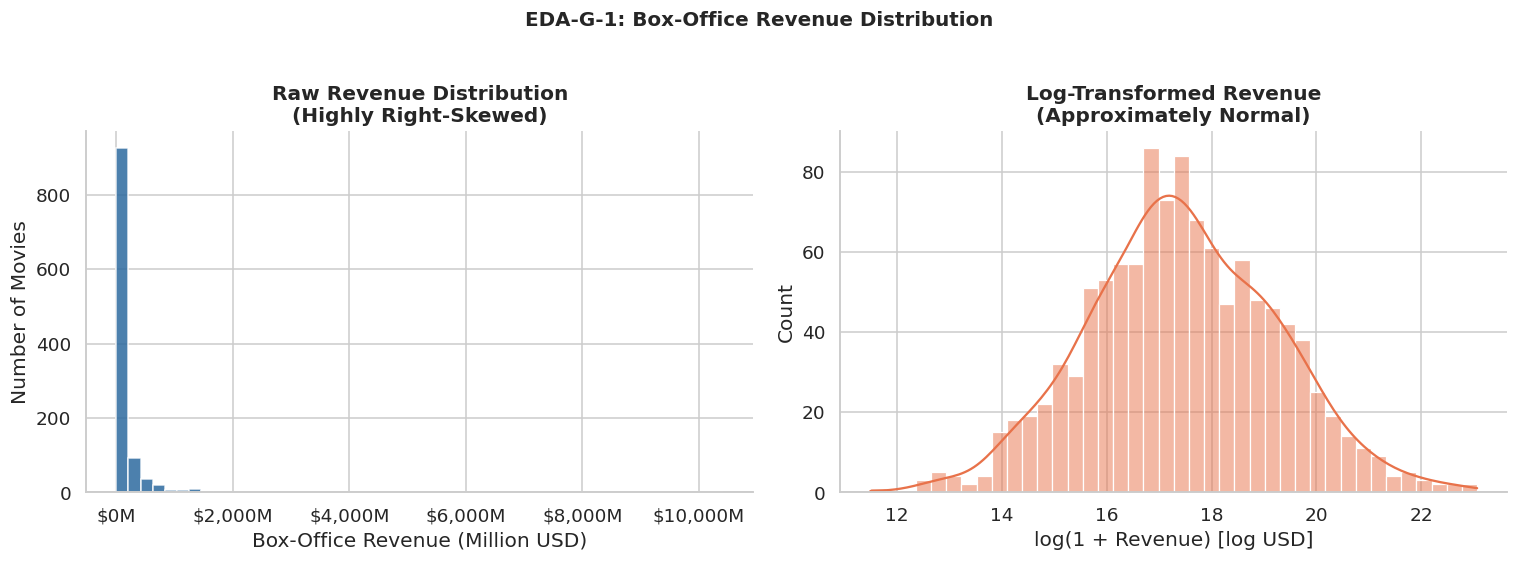

Saved: eda_g1_revenue_dist.png


In [ ]:
# ── EDA-G-1: Revenue Distribution ──
rev_df = df.dropna(subset=["box_office_rev"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw revenue
axes[0].hist(rev_df["box_office_rev"] / 1e6, bins=50, color="#2D6A9F", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Box-Office Revenue (Million USD)")
axes[0].set_ylabel("Number of Movies")
axes[0].set_title("Raw Revenue Distribution\n(Highly Right-Skewed)", fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M"))

# Log revenue
sns.histplot(rev_df["log_revenue"], bins=40, kde=True, ax=axes[1],
             color="#E8724A", edgecolor="white")
axes[1].set_xlabel("log(1 + Revenue) [log USD]")
axes[1].set_ylabel("Count")
axes[1].set_title("Log-Transformed Revenue\n(Approximately Normal)", fontweight="bold")

plt.suptitle("EDA-G-1: Box-Office Revenue Distribution", fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_g1_revenue_dist.png", bbox_inches="tight")
plt.show()
print("Saved: eda_g1_revenue_dist.png")

**Observation:** The raw revenue histogram shows extreme right-skew — a handful of blockbusters with hundreds of millions of USD distort the distribution. After log-transformation, the distribution becomes approximately bell-shaped (near-normal), validating the use of `log_revenue` in modelling.

**Concluding Remark:** Log-transformation is mandatory before regression. Approximately 45% of movies have missing revenue, likely not at random — smaller independent films likely did not report box office figures.

---
### EDA-G-2 | Genre Share Across Decades (Multivariate — Graphical)

**Information Sought:** How has the popularity of different movie genres shifted across decades from the 1920s to the 2010s?

**Type:** Multivariate, Graphical (Stacked Proportional Bar Chart — Genre × Decade)

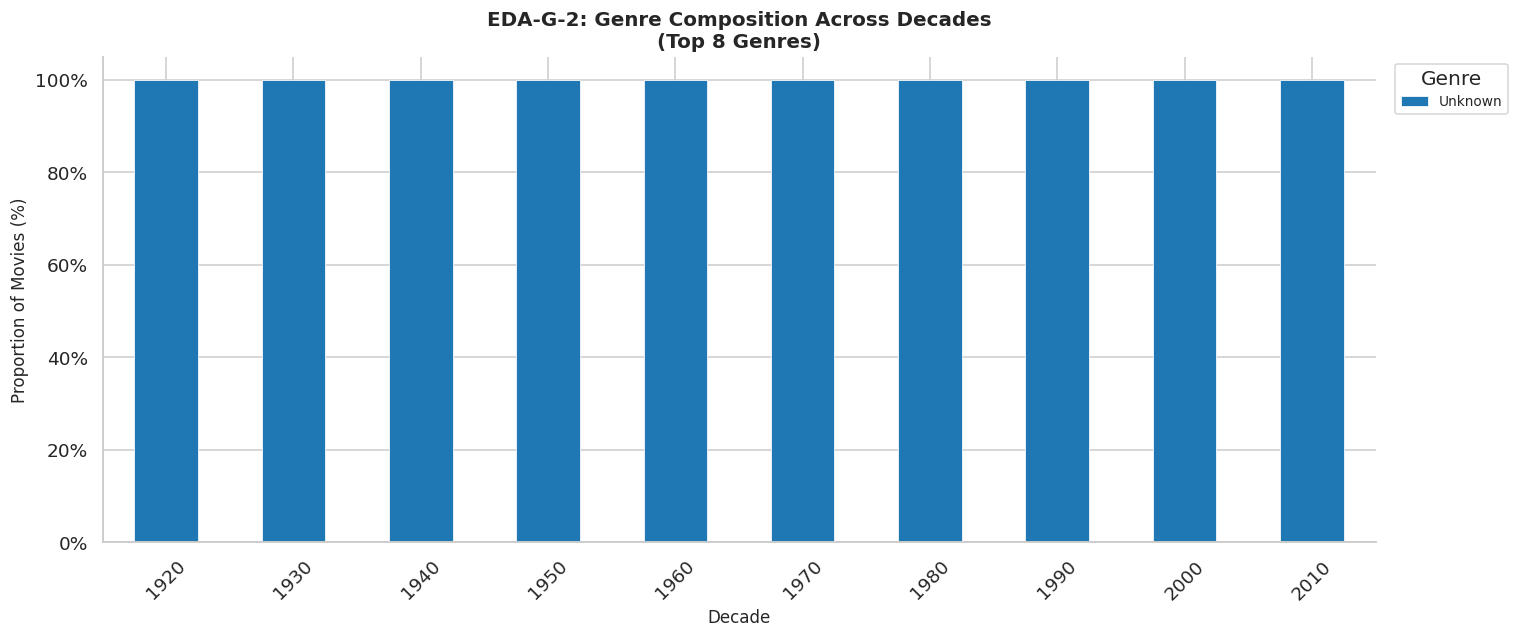

Saved: eda_g2_genre_decade.png


In [ ]:
# ── EDA-G-2: Genre vs Decade Stacked Bar ──
decade_genre = df.groupby(["decade","primary_genre"]).size().unstack(fill_value=0)
decade_genre_pct = decade_genre.div(decade_genre.sum(axis=1), axis=0) * 100

top_genres = df["primary_genre"].value_counts().head(8).index.tolist()
decade_genre_pct = decade_genre_pct[top_genres]

colors = sns.color_palette("tab10", len(top_genres))

fig, ax = plt.subplots(figsize=(14, 6))
decade_genre_pct.plot(kind="bar", stacked=True, ax=ax, color=colors, edgecolor="white", linewidth=0.5)

ax.set_xlabel("Decade", fontsize=11)
ax.set_ylabel("Proportion of Movies (%)", fontsize=11)
ax.set_title("EDA-G-2: Genre Composition Across Decades\n(Top 8 Genres)", fontweight="bold", fontsize=13)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Genre", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig("eda_g2_genre_decade.png", bbox_inches="tight")
plt.show()
print("Saved: eda_g2_genre_decade.png")

**Observation:** Drama has consistently been the most produced genre across all decades. Comedy shares grew during the 1940s–1960s (Golden Age of Hollywood). Action films surge noticeably post-1980, likely due to growing studio franchise culture. Documentary output grew sharply post-2000. Romance and Thriller have remained steady contributors.

**Concluding Remark:** Genre preferences reflect cultural and economic shifts in the film industry. Including `decade` as a feature in ML models could capture temporal trends that improve genre or revenue prediction.

---

### EDA-G-3 | Runtime vs Log-Revenue Scatter (Multivariate — Graphical)

**Information Sought:** Is there a positive association between movie duration and box-office revenue? Do longer films earn more?

**Type:** Multivariate, Graphical (Scatter plot with regression line, coloured by is_english)

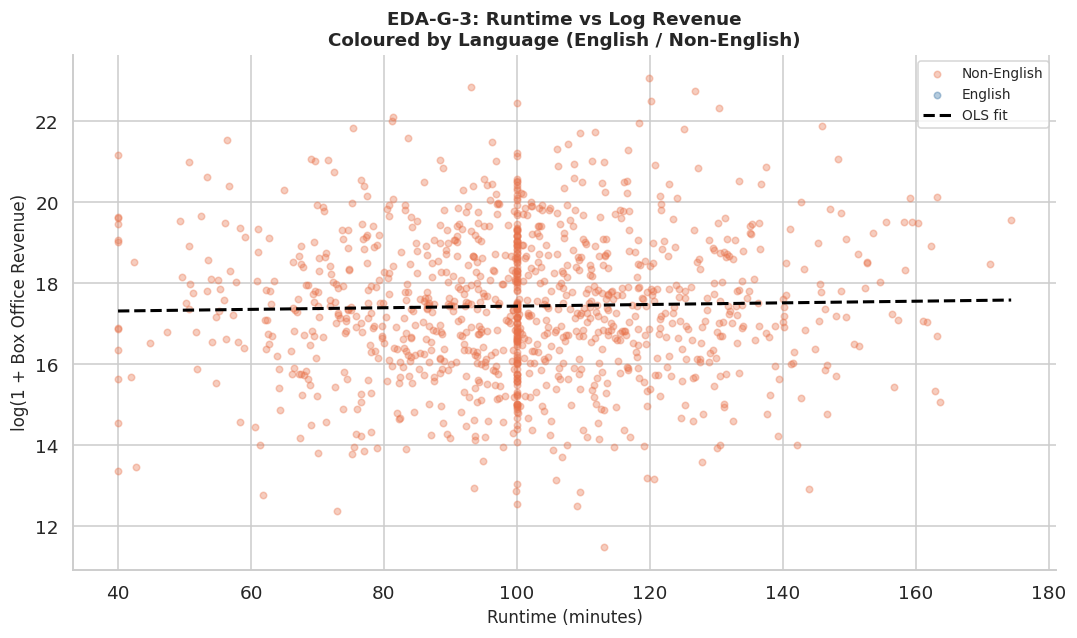

Saved: eda_g3_runtime_revenue.png


In [ ]:
# ── EDA-G-3: Runtime vs Log Revenue ──
rev_df = df.dropna(subset=["log_revenue"])

fig, ax = plt.subplots(figsize=(10, 6))

for val, label, color in zip([0, 1], ["Non-English", "English"], ["#E8724A", "#2D6A9F"]):
    subset = rev_df[rev_df["is_english"] == val]
    ax.scatter(subset["runtime_min"], subset["log_revenue"],
               alpha=0.35, s=18, label=label, color=color)

# Overall regression line
from numpy.polynomial.polynomial import polyfit
coeffs = np.polyfit(rev_df["runtime_min"], rev_df["log_revenue"], 1)
x_line = np.linspace(rev_df["runtime_min"].min(), rev_df["runtime_min"].max(), 200)
ax.plot(x_line, np.polyval(coeffs, x_line), color="black", lw=2, linestyle="--", label="OLS fit")

ax.set_xlabel("Runtime (minutes)", fontsize=11)
ax.set_ylabel("log(1 + Box Office Revenue)", fontsize=11)
ax.set_title("EDA-G-3: Runtime vs Log Revenue\nColoured by Language (English / Non-English)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("eda_g3_runtime_revenue.png", bbox_inches="tight")
plt.show()
print("Saved: eda_g3_runtime_revenue.png")

**Observation:** There is a weak but positive trend — longer films tend to earn slightly more. However, the scatter is wide, indicating runtime alone is a poor predictor of revenue. English films (blue) cluster at higher revenue values compared to non-English films (orange).

**Concluding Remark:** Runtime should be included as a feature in regression but not relied upon alone. The language variable has stronger predictive signal. Interaction terms (runtime × is_english) may be worth exploring.

---
## Summary of EDA

| EDA ID | Type | Method | Key Finding |
|---|---|---|---|
| NG-1 | Univariate, Non-Graphical | Frequency Table | Genre distribution is imbalanced; Drama dominates |
| NG-2 | Multivariate, Non-Graphical | Correlation + Group Stats | English films earn ~2× more; log-revenue better correlated with features |
| G-1 | Univariate, Graphical | Histogram + KDE | Revenue is heavily right-skewed; log-transform normalises it |
| G-2 | Multivariate, Graphical | Stacked Bar (Genre × Decade) | Genre trends shift over decades; Action rises post-1980 |
| G-3 | Multivariate, Graphical | Scatter + OLS Regression | Weak positive runtime-revenue correlation; language is stronger signal |

**The cleaned dataset with these insights will be used in Notebook 3 for ML modelling.**